> Para esse projeto, utilizamos o Modelo PACE (Plan, Analyse, Contruct, Execute) e as 6 práticas de EDA/Análise Exploratória de dados (Descoberta, Estruturação, Limpeza, União, Validação, Apresentação)

# Visão Geral do modelo PACE e EDA (Análise Exploratória de dados)

Pace = estrutura do projeto (macro)
EDA = processo dentro do Analyse (micro)

**P**lan (Planejar)
- Definir o problema de negócio
- Identificar stakeholders (RACI)
- Formular perguntas SMART
- Mapear fontes de dados
- Considerar ética e PII (Personally Identifiable Information, ou Informações de Identificação Pessoal)
  
**A**nalyse (Analisar)
- Descoberta -> `head()`, `shape()` , `dtypes()`,`describe()`,`info()`
- Estruturação -> sort, filter, group, boolean mask, `sort_values()`, `groupby()`
- Limpeza -> nulos, outliers, duplicatas, `dropna()`, `fillna()`, `drop_duplicates()`
- União -> merge, concat, joins, `pd.merge()`, `pd.concat()`
- Validação -> consistência, qualidade, `isnull()`, `duplicated()`, `dtypes()`
- Apresentação -> visualizações exploratórias, matplotlib, seaborn
  
**C**onstruct (Construir)
- Modelos estatísticos e de ML
- feature engineering (engenharia de atributos)
- Validação de modelos
- Criação dos dashboards (plotly, Power BI, Tableau, etc)
  
**E**xecute (Executar)
- Apresentar dos dashboards e resultado da análise para stakeholders
- Comunicar insights
- Receber feedback
- Resumo executivo

> EDA é ITERATIVA:
→ você pode voltar a qualquer etapa
→ o ciclo repete quantas vezes for necessário
→ feedback do Execute pode reiniciar o Analyze

# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plan (Planejar)

> - Definir escopo do projeto.
> - Perguntas SMART a serem respondidas.

**Perguntas a serem respondidas:**
- Quantos funcionários estão ativos na empresa? (headcount)
- Qual é o custo mensal?
- Quais são os departamentos da empresa?
- Qual é a quantidade de funcionários por departamento?
- Existem quantos funcionários por faixa etária?
- Qual é a distribuição de funcionários por gênero?
- Qual é a quantidade de funcionários por ano de contratação?
- Qual o índice de turnover da empresa?

# Analyse (Analisar)

> - Coleta, Limpeza, Análise (EDA)

## 1. Descoberta

In [3]:
funcionarios = pd.read_csv("funcionarios.csv")

In [4]:
funcionarios.head(5)

,Nome do Funcionário,ID Único,Salário,Cargo,Idade,Faixa de Idade,Gênero,Data de Contratação,Status do Funcionário,Departamento,ID da Filial
0,Aline Mendes,DT87832,"R$ 13.163,20",Engenheiro Cloud Sênior,36,35-44,Feminino,05/05/2016,Ativo,Infraestrutura e Cloud,FL05
1,Carlos Rodrigues,DT40595,"R$ 8.987,99",Analista de Dados Pleno,52,45-54,Masculino,16/01/2015,Ativo,Análise de Dados,FL03
2,Cristina Fernandes,DT28643,"R$ 5.997,77",Engenheiro de Dados Júnior,37,35-44,Feminino,07/05/2023,Ativo,Engenharia de Dados,FL07
3,Isabela Vieira,DT67560,"R$ 24.976,41",Lead de Ciência de Dados,62,55+,Feminino,11/01/2019,Inativo,Ciência de Dados,FL08
4,Daniel Monteiro,DT74722,"R$ 5.495,09",Analista de BI Júnior,45,45-54,Masculino,25/03/2017,Ativo,Business Intelligence,FL01


In [22]:
filiais = pd.read_csv("filiais.csv")

In [5]:
funcionarios.shape

(1000, 11)

In [7]:
funcionarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nome do Funcionário    1000 non-null   object
 1   ID Único               1000 non-null   object
 2   Salário                1000 non-null   object
 3   Cargo                  1000 non-null   object
 4   Idade                  1000 non-null   int64 
 5   Faixa de Idade         1000 non-null   object
 6   Gênero                 1000 non-null   object
 7   Data de Contratação    1000 non-null   object
 8   Status do Funcionário  1000 non-null   object
 9   Departamento           1000 non-null   object
 10  ID da Filial           1000 non-null   object
dtypes: int64(1), object(10)
memory usage: 86.1+ KB


## 2. Estruturação

In [8]:
# transforma a coluna de salário em float e remove R$, pontos e vírgulas
funcionarios['Salário'] = (
    funcionarios['Salário']
    .str.replace('R$ ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [9]:
funcionarios.describe().style.format({'Salário': 'R$ {:,.2f}', 'Idade': '{:.0f}'})

,Salário,Idade
count,"R$ 1,000.00",1000
mean,"R$ 13,490.42",42
std,"R$ 6,263.46",13
min,"R$ 3,509.43",18
25%,"R$ 8,017.89",30
50%,"R$ 12,316.90",42
75%,"R$ 18,055.23",54
max,"R$ 29,836.01",62


In [10]:
funcionarios.dtypes

Nome do Funcionário       object
ID Único                  object
Salário                  float64
Cargo                     object
Idade                      int64
Faixa de Idade            object
Gênero                    object
Data de Contratação       object
Status do Funcionário     object
Departamento              object
ID da Filial              object
dtype: object

In [11]:
# Transforma a coluna Data de Contratação em datetime
funcionarios['Data de Contratação'] = pd.to_datetime(funcionarios['Data de Contratação'], format='%d/%m/%Y')

In [12]:
funcionarios.dtypes

Nome do Funcionário              object
ID Único                         object
Salário                         float64
Cargo                            object
Idade                             int64
Faixa de Idade                   object
Gênero                           object
Data de Contratação      datetime64[ns]
Status do Funcionário            object
Departamento                     object
ID da Filial                     object
dtype: object

## 3. Limpeza

In [13]:
# detectar outliers
Q1 = funcionarios['Salário'].quantile(0.25)
Q3 = funcionarios['Salário'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = funcionarios[(funcionarios['Salário'] < limite_inferior) | (funcionarios['Salário'] > limite_superior)]
print(f"Outliers encontrados: {len(outliers)}")
outliers

Outliers encontrados: 0


,Nome do Funcionário,ID Único,Salário,Cargo,Idade,Faixa de Idade,Gênero,Data de Contratação,Status do Funcionário,Departamento,ID da Filial


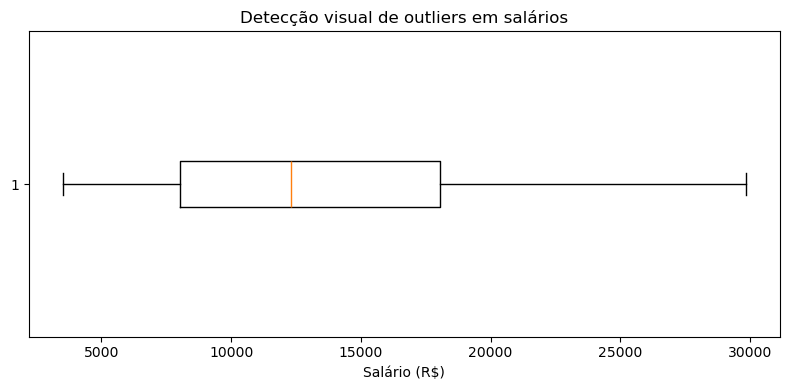

In [14]:
plt.figure(figsize=(8, 4))
plt.boxplot(funcionarios['Salário'], vert=False)
plt.title('Detecção visual de outliers em salários')
plt.xlabel('Salário (R$)')
plt.tight_layout()
plt.show()

In [ ]:
# curso por setor df.groupby('Departamento')['Salário'].sum()

## 4. União

## 5. Validação

In [11]:
# verifica se tem valores ausentes
funcionarios.isnull().sum()

Nome do Funcionário      0
ID Único                 0
Salário                  0
Cargo                    0
Idade                    0
Faixa de Idade           0
Gênero                   0
Data de Contratação      0
Status do Funcionário    0
Departamento             0
ID da Filial             0
dtype: int64

In [13]:
# verifica duplicadas
funcionarios.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

## 6. Apresentação

# Construct (Construir)

> - Criação de modelos estatísticos e de ML

# Execute (Executar)

> - Visualizações Finais
> - Apresentação dos resultados aos stakeholders